## Day 20

Lets start with what we missed from yesterdays:

### Density estimation

This is another branch of unsupervised learning. Within density estimation, We infer the underlying pdf that generated a sample of data. 

Since we only ever get a finite number of samples, the raw data will contain sampling noise. Density estimation attempt to recover the underlying distribution from the discrete observations.

We have already looked at histograms as a way to estimate the density from the data, but this strongly depends on the binwidths and the locations as we have seen before. 

Looking at our Bayes equation:

$$  P(A \mid B) = \frac{P(B \mid A) P(A)}{P(B)}$$

Sometimes, our prior or likelihood, or another distribution we are interested in are not nice well known distributions and can be all over the place (no known analytical form). So if we have samples drawn from that distribution, we can use samples to estimate the pdf.

#### Why is it useful?

- We can identify low probability regions to uncover rare sources 
- If the data can be divided into sub samples, you can estimate the pdf of each subsample and then determine classification for new objects
- It allows us to turn the discrete observations we collected into an estimate of the continuous distribution that generated them.


### Kernel Density Estimation

This is a non-parametric density estimator.

We are basically replacing every observed data point with a smooth function (a kernel). Then we add up all of these kernels together to estimate the overall PDF.


It uses the following equation:

$$p(x) =   \hat{f}_h(x) = \frac{1}{nh} \sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right) $$

Where we have
- $\hat{f}$ is our estimator of the distribution
- $x_i$ is our sampled data
- $K$ is the kernal function
- $h$ is the bandwidth and controls the amount of smoothing
- $n$ is the number of observations

For the bandwidth, if we have a small one, it will give narrow kernals and attempt to produce very detailed and noisy estimates. However, if it is large, we will get smaller estimates but potentially wash away some of the global structure.

Let us see this in use with code:


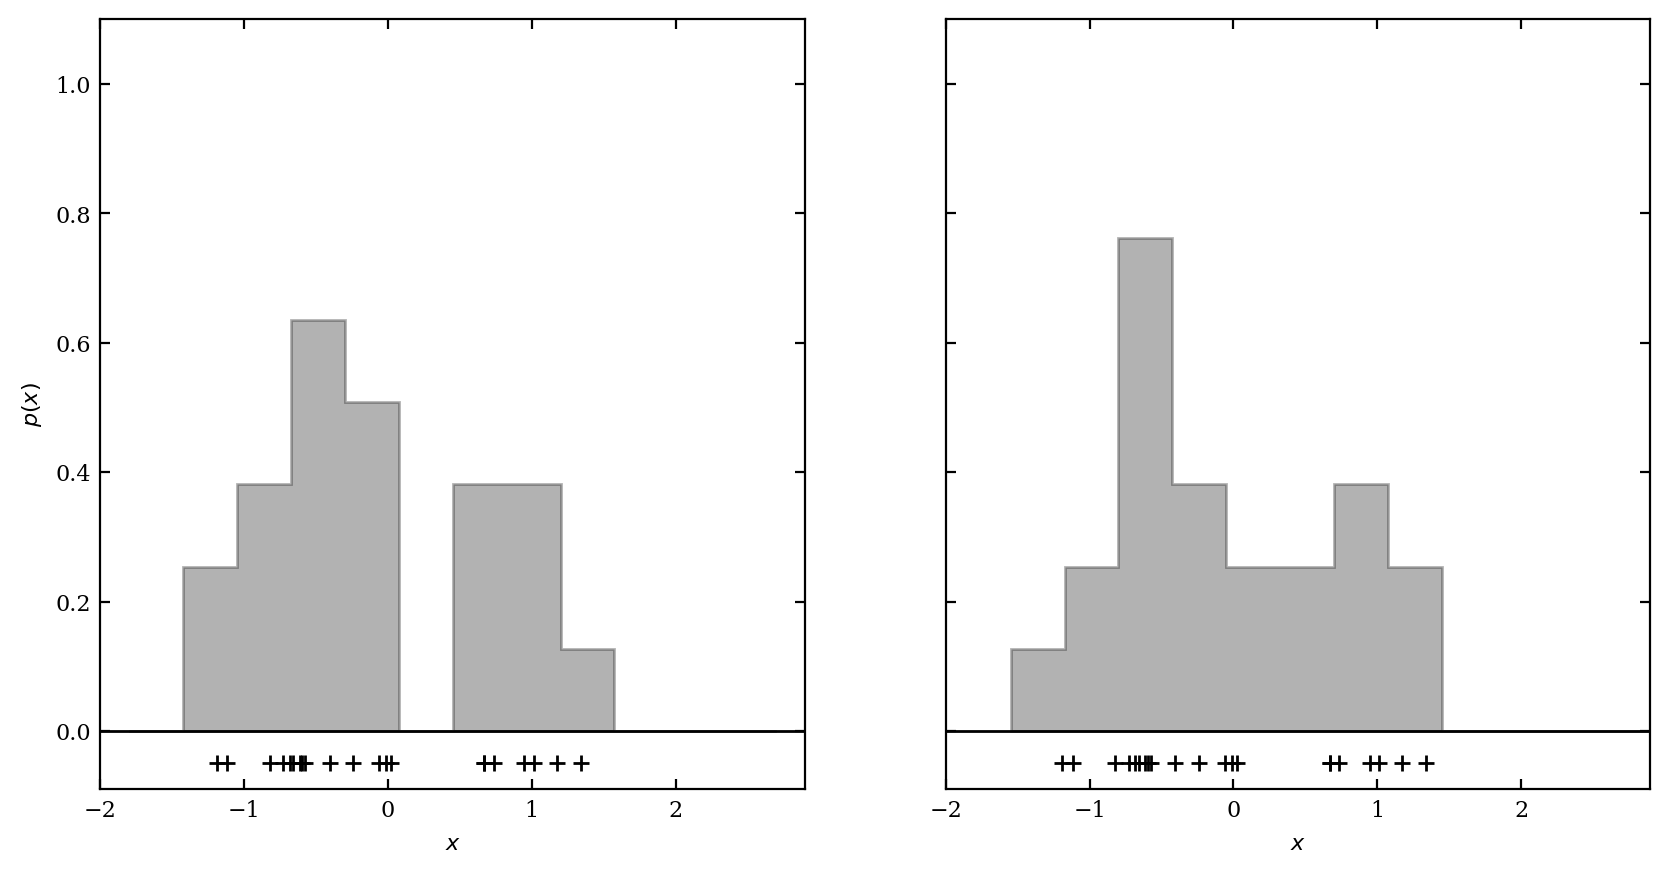

In [30]:
# Execute this cell
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

#------------------------------------------------------------
# Draw some random data
np.random.seed(1)
x = np.concatenate([np.random.normal(-0.5, 0.3, size=14), 
                    np.random.normal(1, 0.3, size=7)])


# Modified from Ivezic, Figure 6.1, modified by GTR
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
#------------------------------------------------------------

# First figure: silly histogram binning
fig1 = plt.figure(figsize=(10, 5))
#fig1.subplots_adjust(left=0.12, right=0.95, wspace=0.05, 
#                    bottom=0.15, top=0.9, hspace=0.05)

FC = '#6666FF'
XLIM = (-2, 2.9)
YLIM = (-0.09, 1.1)

ax = fig1.add_subplot(121)
bins = np.linspace(-1.8, 2.7, 13)
ax.hist(x, bins=bins, density=True, 
        histtype='stepfilled', fc='k', alpha=0.3)
ax.plot(XLIM, [0, 0], '-k', lw=1)
ax.plot(x, 0 * x - 0.05, '+k')
ax.set_xlim(XLIM)
ax.set_ylim(YLIM)
ax.set_xlabel('$x$')
ax.set_ylabel('$p(x)$')

#Shift bin centers by 0.25
ax = fig1.add_subplot(122)
ax.yaxis.set_major_formatter(plt.NullFormatter())
ax.hist(x, bins=bins + 0.25, density=True, 
        histtype='stepfilled', fc='k', alpha=0.3)
ax.plot(XLIM, [0, 0], '-k', lw=1)
ax.plot(x, 0 * x - 0.05, '+k')
ax.set_xlim(XLIM)
ax.set_ylim(YLIM)
ax.set_xlabel('$x$')

plt.show()

Here we have just shifted the location of the bins by 0.25, the data points within both histograms are the same.

We have to also think about what kind of function $K(u)$ can be:
- smooth
- positive definite
- normalises to 1
- has zero mean
- positive variance

To determine the optical kernel bandwidth we use cross validation

0.14655172413793105


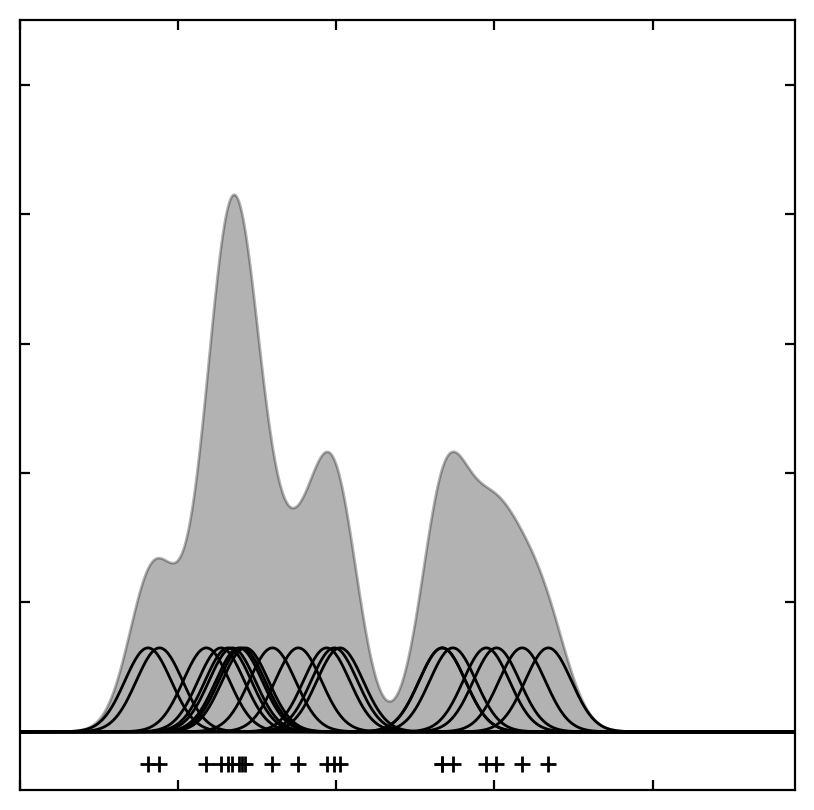

In [31]:
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV

bwrange = np.linspace(0.01,1.0, 30) # Test 30 bandwidths from 0.1 to 1.0
#print(bwrange)
K = 10 # Do 5-fold cross validation
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K) # Try each bandwidth with K-folds
grid.fit(x[:, None]) #Fit the data that we started the lecture with.
h_opt = grid.best_params_['bandwidth']
print(h_opt)

fig2 = plt.figure(figsize=(5, 5))
ax = fig2.add_subplot(111)
ax.xaxis.set_major_formatter(plt.NullFormatter())
ax.yaxis.set_major_formatter(plt.NullFormatter())

binwidth = bins[1] - bins[0]
x_grid = np.linspace(-4, 4, 1000)
y_plot = binwidth * stats.norm.pdf(x_grid, x[:, None], h_opt)
y_plot /= (binwidth * len(x))

ax.fill(x_grid, y_plot.sum(0), ec='k', lw=1, fc='k', alpha=0.3)
ax.plot(x_grid, y_plot.T, '-k', lw=1)
ax.plot(x, 0 * x - 0.05, '+k')

ax.set_xlim(XLIM)
ax.set_ylim(YLIM);

We can see how each kernel added together to make a pdf.

#### 2D KDE

Here is an example of a 2D implementation:

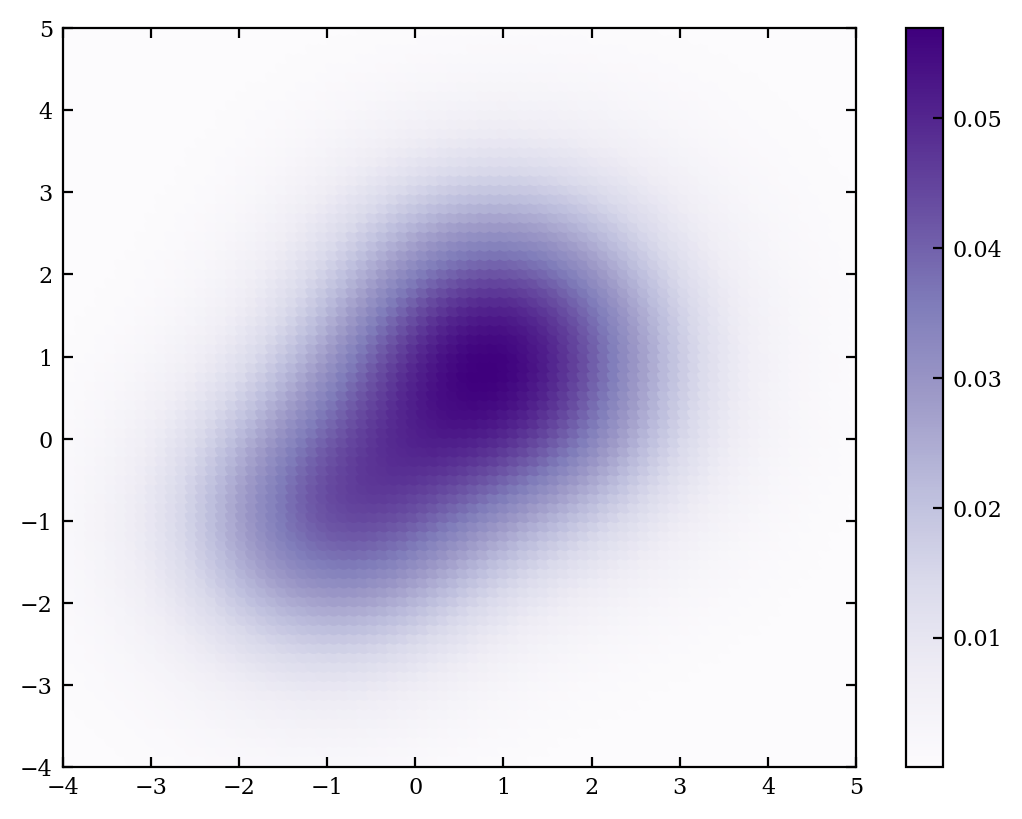

In [32]:
from sklearn.neighbors import KernelDensity

# Two 2-D normal distributions with offset centroids
# See what happens when you make changes to the next 2 lines.
X = np.concatenate([np.random.normal([-1,-1],[0.75,0.75], size=(500,2)), 
                    np.random.normal([1,1],[1,1], size=(1000,2))]) 
kde = KernelDensity(kernel='gaussian', bandwidth=0.99)
kde.fit(X) #fit the model to the data

u = v = np.linspace(-4,5,80)
Xgrid = np.vstack(list(map(np.ravel, np.meshgrid(u, v)))).T
dens = np.exp(kde.score_samples(Xgrid)) #evaluate the model on the grid

plt.scatter(Xgrid[:,0], Xgrid[:,1], c=dens, 
            cmap="Purples", edgecolor="None")
plt.colorbar();

### Nearest-Neighbour Density Estimation

Instead of fixing a bandwidth as in KDE, nearest-neighbour density estimation fixes the number of neighbours $K$ and finds the distance $d_K$ required to reach the $K$ th neighbour.

$$\hat{f}_K(x)=\frac{K}{V_D(d_K)}$$

Dense regions have a small $d_K$ and therefore a high estimated density, while bare/sparse regions require a larger volume.

Small $K$ gives higher spatial resolution but more noise, while large $K$ gives a smoother estimate but can wash out small-scale structure.

Unlike KDE with a fixed bandwidth, the effective smoothing scale adapts to the local density.



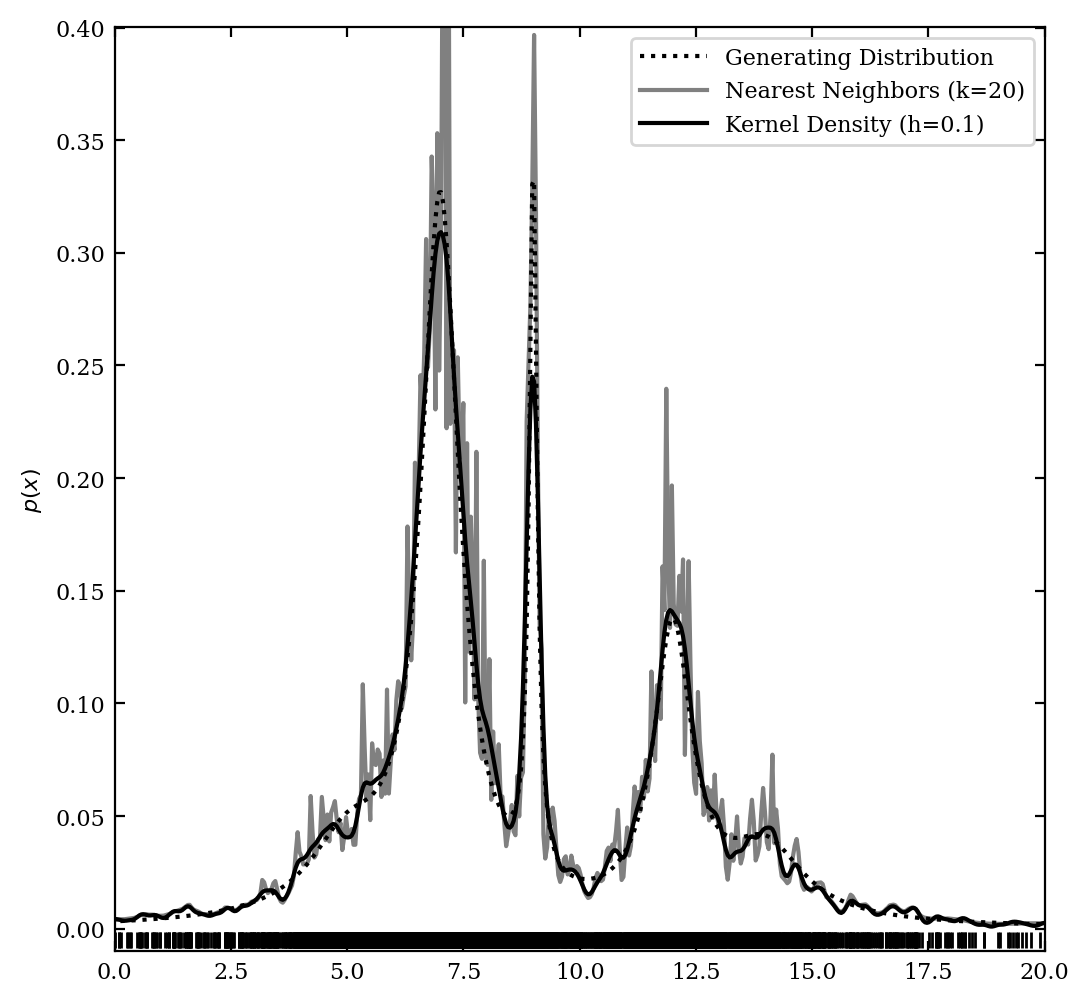

In [33]:
# Based on Ivezic, Figure 6.5
# Modified by GTR
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general

from astroML.density_estimation import KNeighborsDensity
from astropy.visualization import hist
from sklearn.neighbors import KernelDensity

#------------------------------------------------------------
# Generate our data: a mix of several Cauchy distributions
#  this is the same data used in the Bayesian Blocks figure
np.random.seed(0)
N = 10000
mu_gamma_f = [(5, 1.0, 0.1),
              (7, 0.5, 0.5),
              (9, 0.1, 0.1),
              (12, 0.5, 0.2),
              (14, 1.0, 0.1)]
true_pdf = lambda x: sum([f * stats.cauchy(mu, gamma).pdf(x) 
                          for (mu, gamma, f) in mu_gamma_f])
x = np.concatenate([stats.cauchy(mu, gamma).rvs(int(f * N)) 
                    for (mu, gamma, f) in mu_gamma_f])
np.random.shuffle(x)
x = x[x > -10]
x = x[x < 30]

#------------------------------------------------------------
# plot the results
fig = plt.figure(figsize=(6, 6))
N = 5000
k = 20 #Number of neighbors

xN = x[:N]
t = np.linspace(-10, 30, 1000)

# Compute density with KDE
kde = KernelDensity(bandwidth=0.1, kernel='gaussian')
kde.fit(xN[:, None])
dens_kde = np.exp(kde.score_samples(t[:, None]))

# Compute density with Bayesian nearest neighbors
nbrs = KNeighborsDensity('bayesian', n_neighbors=k)
nbrs.fit(xN[:, None])
dens_nbrs = nbrs.eval(t[:, None]) / N

# plot the results
plt.plot(t, true_pdf(t), ':', color='black', 
         zorder=3, label="Generating Distribution")
plt.plot(xN, -0.005 * np.ones(len(xN)), '|k')
plt.plot(t, dens_nbrs, '-', lw=1.5, color='gray', 
         zorder=2, label="Nearest Neighbors (k=%i)" % k)
plt.plot(t, dens_kde, '-', color='black', 
         zorder=3, label="Kernel Density (h=0.1)")

# label the plot
plt.ylabel('$p(x)$')
plt.legend(loc='upper right')
plt.xlim(0, 20)
plt.ylim(-0.01, 0.4001)

plt.show()


### There is also Gaussian Mixture models but we have looked at this, at some point I will come back and add it here.

## Lecture 17 - Regression

### Regression

Regression is a supervised learning method used to determine the relationship between one or more independent variables/features $x$ and a continuous dependent/target variable $y$.

The quantity we are trying to estimate is essentially the expectation value of $y$ given $x$:

$$E[y|x]$$

We can imagine that there is some underlying relationship together with some noise or scatter:

$$y_i=f(x_i)+\epsilon_i$$

where $f(x_i)$ is the underlying relationship we are trying to learn and $\epsilon_i$ represents noise, intrinsic scatter, measurement uncertainty, missing variables, etc.

Most metrics used for regression are based on **residuals**, which are the differences between the true and predicted values:

$$r_i=y_i-\hat{y}_i$$

### Evaluating how good the regression is

We can use metrics such as the Mean Absolute Error (MAE), Mean Squared Error (MSE) and Root Mean Squared Error (RMSE).

Denoting $y$ as the true values and $\hat{y}$ as the predictions, for $N$ observations:

$$\text{MAE}=\frac{1}{N}\sum_{i=1}^{N}|y_i-\hat{y}_i| \qquad \text{MSE}=\frac{1}{N}\sum_{i=1}^{N}(y_i-\hat{y}_i)^2 \qquad \text{RMSE}=\sqrt{\frac{1}{N}\sum_{i=1}^{N}(y_i-\hat{y}_i)^2}$$

MAE treats errors linearly, while MSE penalises larger errors more strongly because the residuals are squared. RMSE has the same units as the target variable.

When a quantity such as MSE or MAE is actually minimised during fitting, it acts as a **loss function**.

Another measure of regression performance is $R^2$, the coefficient of determination. This measures how well the model explains the variation in the target $y$ compared with simply predicting the mean.

The total sum of squares is:

$$\text{SS}_{\text{tot}}=\sum_{i=1}^{N}(y_i-\bar{y})^2$$

This measures the total variation in the observed values around their mean.

The residual sum of squares is:

$$\text{SS}_{\text{res}}=\sum_{i=1}^{N}(y_i-\hat{y}_i)^2$$

This measures the variation left unexplained by the regression model.

The coefficient of determination is then:

$$R^2=1-\frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$$

$R^2=1$ corresponds to perfect predictions, $R^2=0$ means the model performs no better than constantly predicting $\bar{y}$, and $R^2<0$ means it performs worse than this baseline.

### Linear Regression

We now need to choose a form for the underlying relationship $f(x)$. The simplest useful choice is linear regression.

For one predictor $x$, we assume:

$$f(x)=\beta_0+\beta_1x$$

where $\beta_0$ is the intercept and $\beta_1$ is the slope.

Including the scatter in the observations:

$$y_i=\beta_0+\beta_1x_i+\epsilon_i$$

The aim is therefore to answer: **if I know $x$, what value of $y$ should I expect on average?**

The prediction made by the fitted model is:

$$\hat{y}_i=\beta_0+\beta_1x_i$$

If we have more than one predictor/feature, we use **multiple linear regression**:

$$y_i=\beta_0+\sum_{j=1}^{p}\beta_jX_{ij}+\epsilon_i$$

where $X_{ij}$ is feature $j$ for observation $i$, and each $\beta_j$ determines how strongly that feature contributes to the prediction.

### How do we decide which line is best?

For a particular choice of $\beta_0$ and $\beta_1$, the residual is:

$$r_i=y_i-\hat{y}_i=y_i-(\beta_0+\beta_1x_i)$$

A single residual tells us how wrong one prediction is, but we need a way to quantify the error of the entire model.

#### Ordinary Least Squares

Ordinary Least Squares (OLS) finds the parameters which minimise the total squared residuals.

The Residual Sum of Squares is:

$$\mathrm{RSS}=\sum_{i=1}^{N}r_i^2$$

Substituting the linear model:

$$\mathrm{RSS}=\sum_{i=1}^{N}\left[y_i-(\beta_0+\beta_1x_i)\right]^2$$

We therefore choose $\beta_0$ and $\beta_1$ to minimise RSS:

$$(\hat{\beta}_0,\hat{\beta}_1)=\underset{\beta_0,\beta_1}{\operatorname{argmin}}\sum_{i=1}^{N}\left[y_i-(\beta_0+\beta_1x_i)\right]^2$$

This is closely related to MSE:

$$\mathrm{MSE}=\frac{\mathrm{RSS}}{N}$$

Since $N$ is constant, minimising MSE and minimising RSS produce the same best-fitting parameters.

Intercept: 1.865032551754254
Slope: 3.0452356957477513


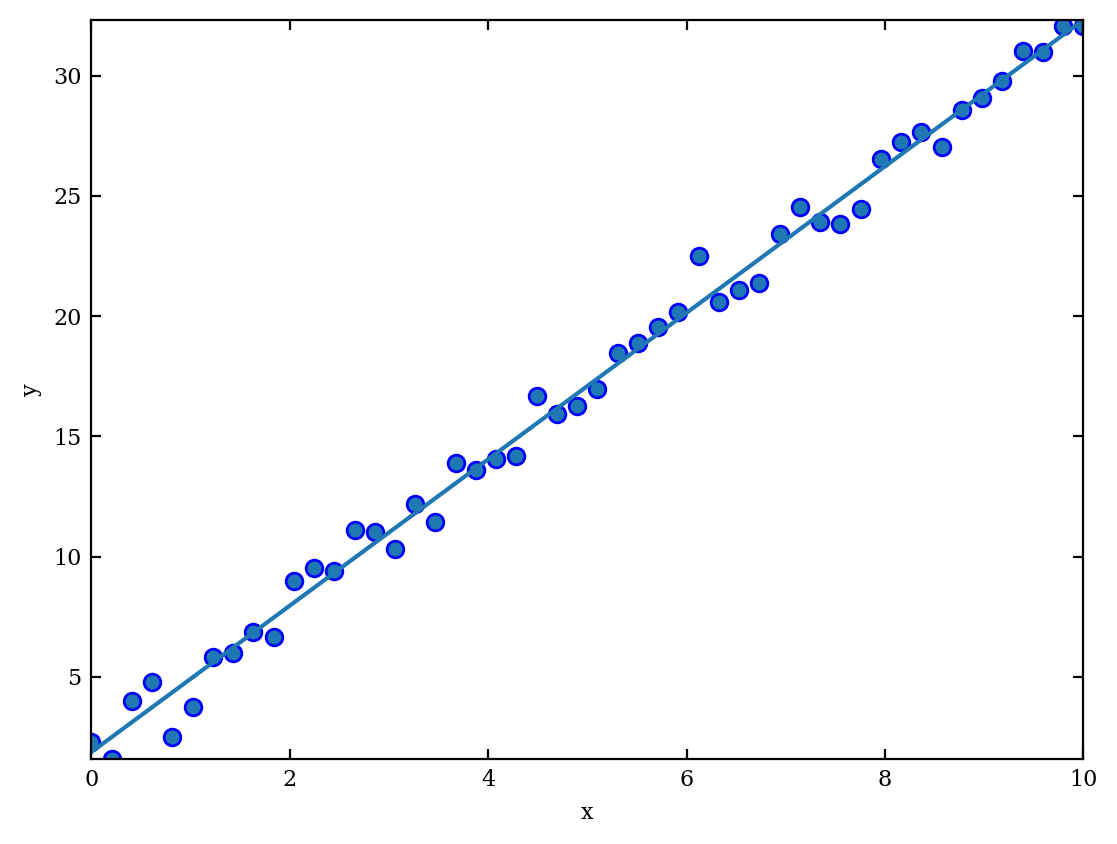

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(42)

x = np.linspace(0, 10, 50)
y = 2 + 3*x + rng.normal(0, 1, size=len(x))

X = x.reshape(-1, 1)

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

plt.scatter(x, y)
plt.plot(x, y_pred)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### Homoscedastic error minimisation

So we are looking for regressions where the scatter has the same size everywhere, and we would get 

$$\theta_1 = \frac{\sum_i^N x_i y_i - \bar{x}\bar{y}}{\sum_i^N(x_i-\overline{x})^2},$$

and 

$$\theta_0 = \overline{y} - \theta_1\overline{x},$$

where $\bar{x}$ and $\bar{y}$ are the mean values

Then we find that the standard errors and variance of the estimated parameters are:

$$\sigma^2 = \sum_{i=1}^N (y_i - \theta_0 + \theta_1 x_i)^2, \qquad \qquad \sigma_{\theta_1}^2 = \sigma^2\frac{1}{\sum_i^N(x_i-\overline{x})^2}, \qquad \qquad \sigma_{\theta_0}^2 = \sigma^2\left(\frac{1}{N} + \frac{\overline{x}^2}{\sum_i^N(x_i-\overline{x})^2}\right).$$


### Heteroscedastic error scenario

If the errors are different for each point, we think of it in matrix notation:

$$Y = M \theta$$

Where $Y$ is a N-dimension vector of values $y_i$

$$Y = \left[
    \begin{array}{c}
    y_0\\
    \vdots\\
    y_{N-1}
    \end{array}
    \right].$$

And for a straight line model, $\theta$ is the 2D vector of regression coefficients:

$$\theta = \left[
            \begin{array}{c}
            \theta_0\\
            \theta_1
            \end{array}
          \right],$$

And $M$ is the design matrix:

$$M = \left[
        \begin{array}{cc}
        1 & x_0\\
        \vdots & \vdots\\
        1 & x_{N-1}
        \end{array}
    \right],$$

Where the first column represents the zero point (within linear regression its the y-intercept)

Then the log-likelihood can be written as such:

$$\ln\mathcal(L) = -\frac{1}{2}(Y-M\theta)^T C^{-1} (Y-M\theta) - \frac{1}{2}\ln[\mathrm{det}(C)]$$

Where the uncertainties are captured in the $N \times N$ covariance matrix

$$C=\left[
        \begin{array}{cccc}
        \sigma_{0}^2 & 0 & \cdots & 0 \\
        \vdots & \vdots & \cdots & \vdots \\
        0 & 0 & \cdots & \sigma_{N-1}^2 \\
        \end{array}
    \right].$$

Then the maximum likelihood solution for the regression is:

$$\theta = (M^T C^{-1} M)^{-1} (M^T C^{-1} Y),$$

This minimises the sum of the squares and gives uncertainties on $\theta$ of 

$$\Sigma_\theta = \left[
                    \begin{array}{cc}
                    \sigma_{\theta_0}^2 & \sigma_{\theta_0\theta_1} \\
                    \sigma_{\theta_0\theta_1} & \sigma_{\theta_1}^2
                    \end{array}
                  \right]
                    = [M^T C^{-1} M]^{-1}.$$

Let us look at an example!

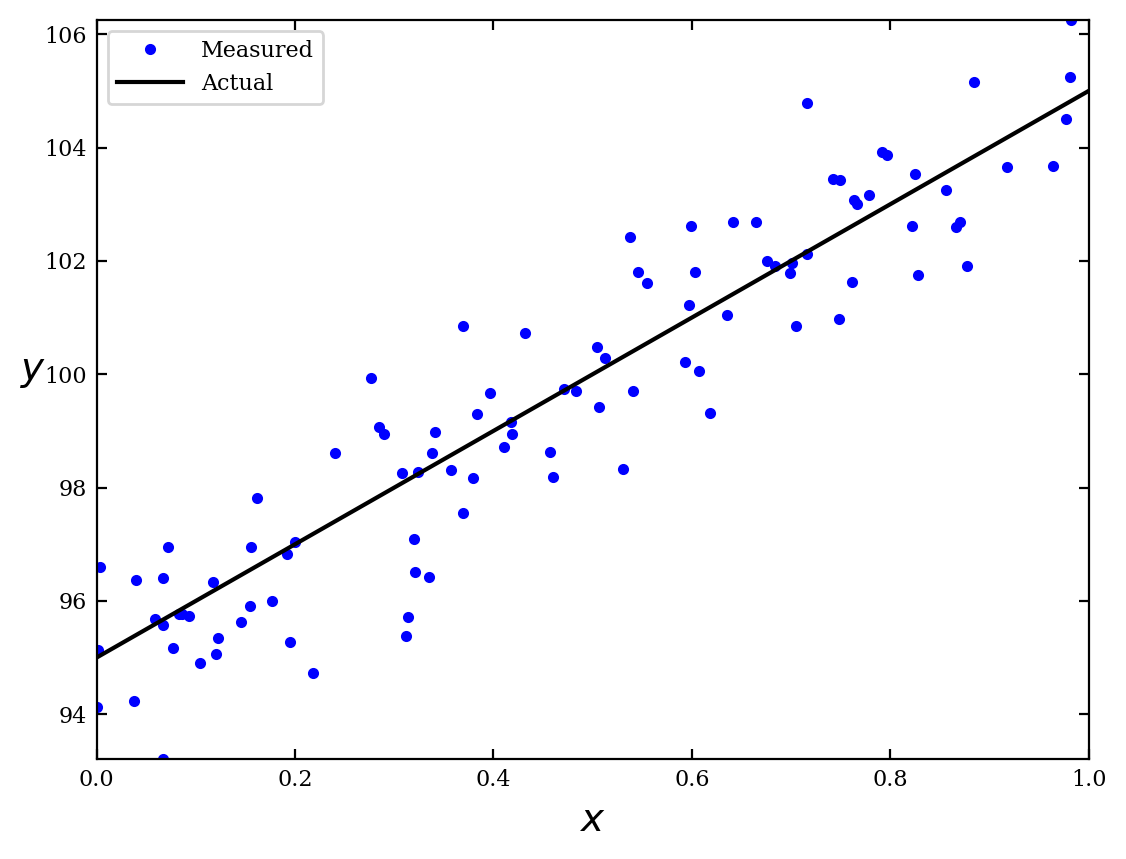

In [35]:
# Generate the noisey data 
theta0 = 95 # Known value of b (theta0)
theta1 = 10 # Known value of m (theta1)
noise_std = 1.0 
noise = np.random.randn(100, 1) * noise_std
dy = noise

X = np.random.rand(100, 1)
y = theta0 + theta1 * X + dy

X_grid = np.linspace(0,1,11)
y_true = theta0 + theta1*X_grid

plt.plot(X, y, "b.", label='Measured')
plt.plot(X_grid, y_true, "k-", label='Actual')
plt.xlabel("$x$", fontsize=14)
plt.ylabel("$y$", rotation=0, fontsize=14)
plt.legend()
plt.show()

In [36]:
# diagonal noise matrix
C = np.identity(len(X[:,0])) * noise_std**2

# design matrix
M = np.column_stack((np.ones(len(X[:,0])), X[:,0]))

# Sigma^-1 = M^T * C^-1 * M
A = np.dot(np.dot(M.T, np.linalg.pinv(C)), M)

# M^T * C^-1 * y
B = np.dot(np.dot(M.T, np.linalg.pinv(C)), y)

# theta = Sigma * M^T * C^-1 * y
theta = np.dot(np.linalg.pinv(A),B)
print(theta)

[[94.75365834]
 [10.31439647]]


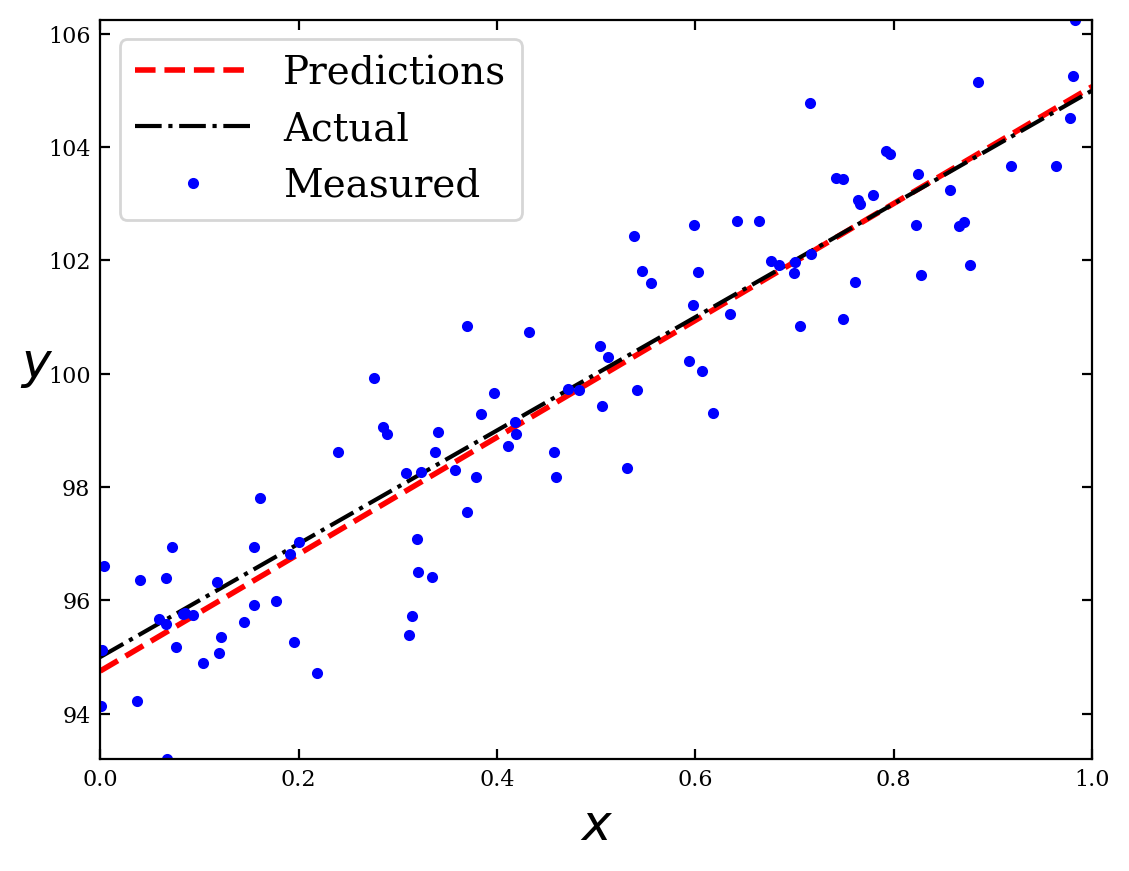

In [37]:
X_new = np.array([[0], [1]]) #like X_grid, but just with the endpoints
y_pred = theta[0] + theta[1]*X_new  # Complete 

plt.plot(X_new, y_pred, "r--", linewidth=2, label="Predictions")
plt.plot(X_grid, y_true, "k-.", label="Actual") # Comment this out to see that it agrees with the above
plt.plot(X, y, "b.", label='Measured')
plt.xlabel("$x$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.show()

#N.B. you could also do this as 
#y_pred = np.dot(MM,theta)
#if MM were defined appropriately
#MM = np.column_stack((np.ones(len(X_grid)),X_grid))
#y_pred = np.dot(MM,theta)
#plt.plot(MM[:,1], y_pred, "r--", linewidth=2, label="Predictions")

This is all doing it semi manually, but it is much easier with Scikitlearn:

In [38]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y, sample_weight=1.0)

theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_

print(theta0, theta1)
y_pred2 = lin_reg.predict(X_new)

[94.75365834] [[10.31439647]]


Compare what we solved ourselves with what we solved with scikitlearn:

In [39]:
print(y_pred)
print(y_pred2)

[[ 94.75365834]
 [105.06805481]]
[[ 94.75365834]
 [105.06805481]]


### Multivariate Linear Regression

If we instead want a 2D linear regression with a multivariate $X$, we fit a hyperplane, not a straight line.

It is not tricky to implement:

In [40]:
from astroML.linear_model import LinearRegression

Xtest = np.random.random((100,2)) # 100 points in 2D
dytest = np.random.random(100) # heteroscedastic errors
ytest = np.random.normal(Xtest[:,0] + Xtest[:,1], dytest) # y = 0 + 1*x1 + 1*x2

model = LinearRegression()
model.fit(Xtest, ytest, dytest)

print(model.coef_)


[0.00675516 0.98120721 1.0020098 ]


### Polynomial Regression

We can think of linear regression more generically with:

$$y_i =\theta_0 + \theta_1 x_{i} + \theta_2 x_{i}^2 + \theta_3 x_{i}^3 + \cdots.$$

For this, the design matrix is

$$M = \left(
        \begin{array}{cccccc}
        1 & x_{0} & x_{0}^2 & x_{0}^3\\
        1 & x_{1} & x_{1}^2 & x_{1}^3\\
        . & . & . & . \\
        1 & x_{N} & x_{N}^2 & x_{N}^3\\
        \end{array}
    \right)$$

This can be done with:



In [41]:
# Typical call
from astroML.linear_model import PolynomialRegression

Xtest = np.random.random((100,1))
ytest = 2.5*Xtest[:,0]**2 + 5.0*Xtest[:,0]**3

degree = 3
model = PolynomialRegression(degree) # fit 3rd degree polynomial
model.fit(Xtest, ytest)

y_pred = model.predict(Xtest)
n_constraints = degree + 1

print(model.coef_)

[-3.74620311e-16  1.33226763e-15  2.50000000e+00  5.00000000e+00]


### Basis function regression

Here we think of the function in terms of a sum over bases (this is thinking of them as different distributions, whether polynomials, guassians, sines etc and adding them up to get the function we want). We can then solve for the linear amplitude coefficients using regression. So regression with arbitrary basis terms that may be non linear in $x$ is still linera regression **since the model is linear in the regression parameters**


So we are linearly combining a set of simple functions (these will be of the dependant variable)

These basis functions can be:
- **global** meaning it covers the entire interval so an outlier changes the value of every prediction
- **local** it means there are multiple basis functions and each one covers its own interval and hence the outlier changes the respective interval
- **relatively local** means that it is theoretically global but the change it experiences is so small that it behaves as if it was local.

Further explanation: [Per Starke - Basis Functions](https://www.youtube.com/watch?v=xTo8Q9asVfc)


In [42]:
#Basis function regression looks like this
from astroML.linear_model import BasisFunctionRegression

# data
Xtest = np.random.random((100,1))

ytest = np.random.normal(Xtest[:,0], dytest)

# mean positions of the 10 Gaussians in the model
X_gridtest = np.linspace(0,1,10)[:, None]
# widths of these Gaussians
sigma_test = 0.1

model = BasisFunctionRegression('gaussian', mu=X_gridtest, sigma=sigma_test)
model.fit(Xtest, ytest, dytest)

y_pred = model.predict(Xtest)
print(model.coef_)

[ 6.62923054e-01 -2.71901045e-02 -1.08687747e-01 -6.17306353e-02
 -1.72801446e-02 -3.41653277e-02  5.59501075e-04 -4.11348168e-02
  9.76650978e-02 -3.53899141e-02  9.69025618e-02]


### Kernel Regression

In the case of Gaussian Basis Regression, we get gaussians that are spaced evenly over the range of interest, however if we place gaussians at the location of every datapoint, we have a Gaussian kernel regression instead. Or Kernel Regression. Or Nadaraya-Watson Regression.

Given a kernel $K(x_i, x)$ e.g a gaussian or a top-hat. At each point we estimate the function value by calculating a weighted average of the observations $y_i$.

$$f(x|K) = \frac{\sum_{i=1}^N K\left( \frac{||x_i-x||}{h} \right) y_i}
{\sum_{i=1}^N K\left( \frac{||x_i-x||}{h} \right)},$$

The weight assigned to each observation $y_i$, depends on its distance from a query point $x$

$$w_i(x) = \frac{ K\left( \frac{||x_i-x||}{h} \right)}
{\sum_{i=1}^N K\left( \frac{||x_i-x||}{h} \right)}.$$

We use cross validation to find the correct bandwidth of the kernel as we have seen before.

We can implement the Nadaraya-Watson Regression as such:

In [43]:
from astroML.linear_model import NadarayaWatson

Xtest = np.random.random((100,2))
ytest = Xtest[:,0] + Xtest[:,1]

model = NadarayaWatson(kernel='gaussian', h=0.05)
model.fit(Xtest,ytest)

y_pred = model.predict(Xtest)
y_pred

array([0.95131723, 1.20393397, 1.28895273, 1.87152735, 1.5100308 ,
       0.51533832, 0.94169164, 0.46684963, 1.5196972 , 0.70112582,
       1.41088674, 1.50090678, 0.94867781, 0.30414179, 0.97277733,
       1.1235695 , 1.38718281, 0.26162051, 1.14595628, 1.17116613,
       0.73548887, 1.02191203, 1.49178866, 0.68733393, 0.84195375,
       1.33800873, 1.34786509, 0.41075069, 1.56879573, 0.55335166,
       1.06682322, 0.74542553, 0.69752211, 1.07597262, 0.96148081,
       0.54072227, 1.62315452, 1.22414102, 1.01400258, 0.83821467,
       0.85123767, 1.38392472, 1.33559559, 0.94020299, 1.06635418,
       0.82857576, 0.63205799, 1.14138153, 0.83109594, 0.7596491 ,
       0.54859741, 0.65404197, 0.97018114, 0.6963248 , 1.08060132,
       1.40215698, 1.31439795, 0.94079629, 0.90304394, 1.05534057,
       1.44924209, 1.04333108, 0.85615042, 0.93905557, 0.12192163,
       1.15359612, 1.47605155, 0.68553499, 1.14513805, 0.89407263,
       1.19735707, 0.74153778, 1.34392187, 1.86229957, 1.26285

### Over/Under fitting

We can look at a function 

$$y_i = x_i \sin(x_i) + \epsilon_i,$$

Where $\epsilon_i$ is given by $\mathscr{N}(0,0.1)$

And see what underfitting and overfitting looks like:

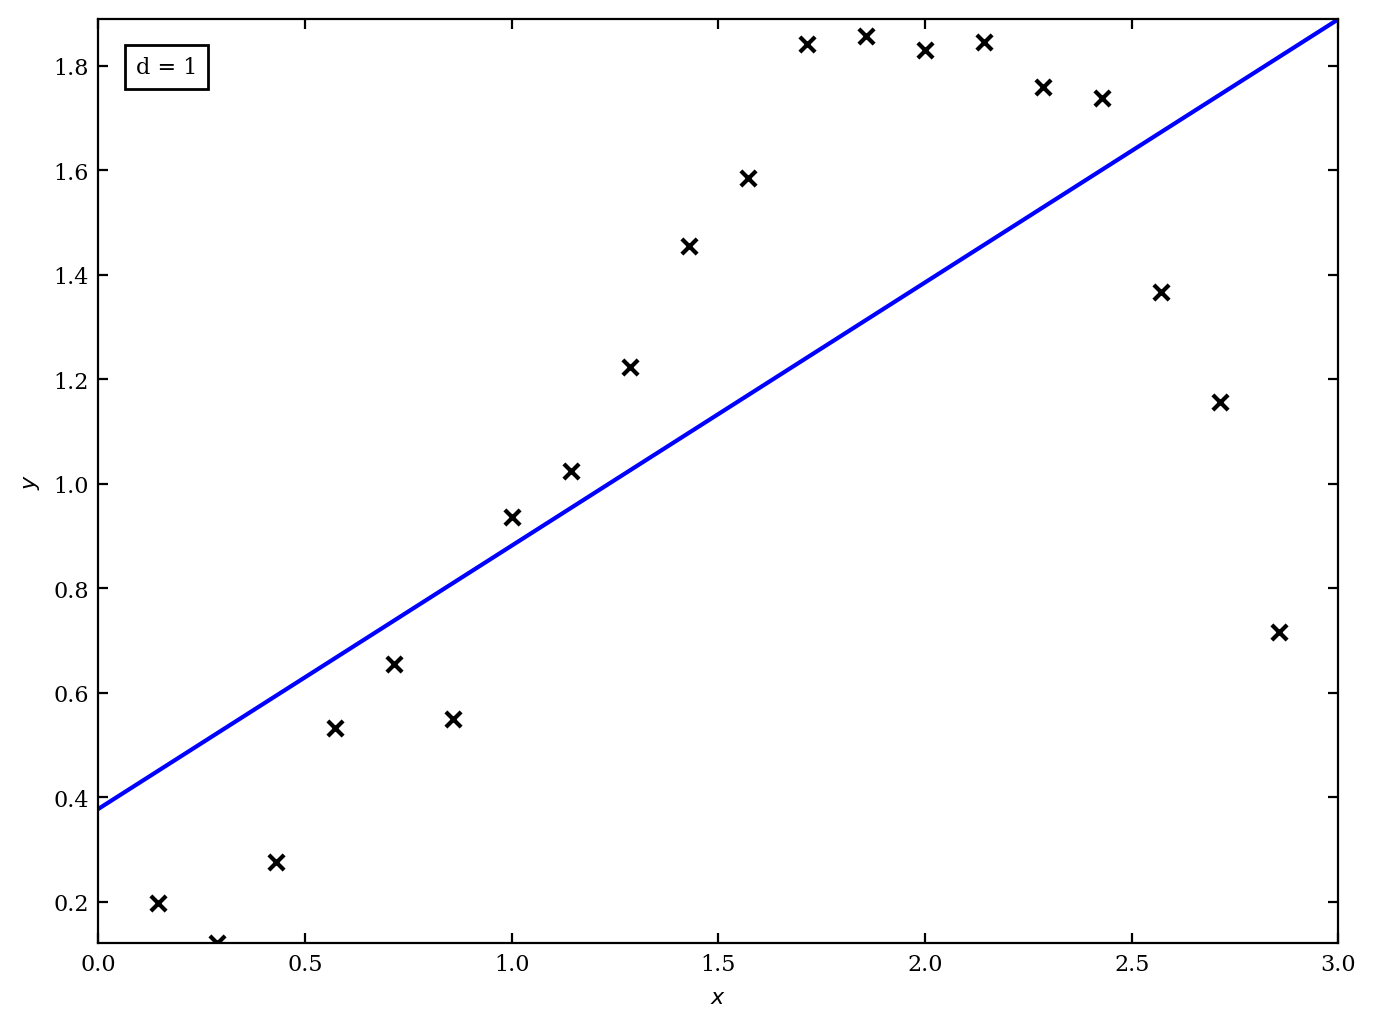

In [44]:
# Ivezic v2, Figure 8.12, plot made bigger by SRT and GTR
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from matplotlib import ticker
from matplotlib.patches import FancyArrow

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

#------------------------------------------------------------
# Define our functional form
def func(x, dy=0.1):
    return np.random.normal(np.sin(x) * x, dy)

#------------------------------------------------------------
# select the (noisy) data
np.random.seed(0)
x = np.linspace(0, 3, 22)[1:-1]
dy = 0.1
y = func(x, dy)

#------------------------------------------------------------
# Select the cross-validation points
np.random.seed(1)
x_cv = 3 * np.random.random(20)
y_cv = func(x_cv)

x_fit = np.linspace(0, 3, 1000)

#------------------------------------------------------------
# First figure: plot points with a linear fit
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

ax.scatter(x, y, marker='x', c='k', s=30)

p = np.polyfit(x, y, 1)
y_fit = np.polyval(p, x_fit)

ax.text(0.03, 0.96, "d = 1", transform=plt.gca().transAxes,
        ha='left', va='top',
        bbox=dict(ec='k', fc='w'))

ax.plot(x_fit, y_fit, '-b')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')

plt.show()

This is the same as the figure in Izevic

We can see that the straight line is not a good fit for the data we have, and as such the model is biased and underfits the data.
> It is biased as the estimated model parameters deviate significantly from the true model parameters.

Let's increase the degree of the polynomial (since our straight line is a polynomial of degree 1):



C:\Users\krist\AppData\Local\Temp\ipykernel_6112\2206860561.py:51: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x, y, d)


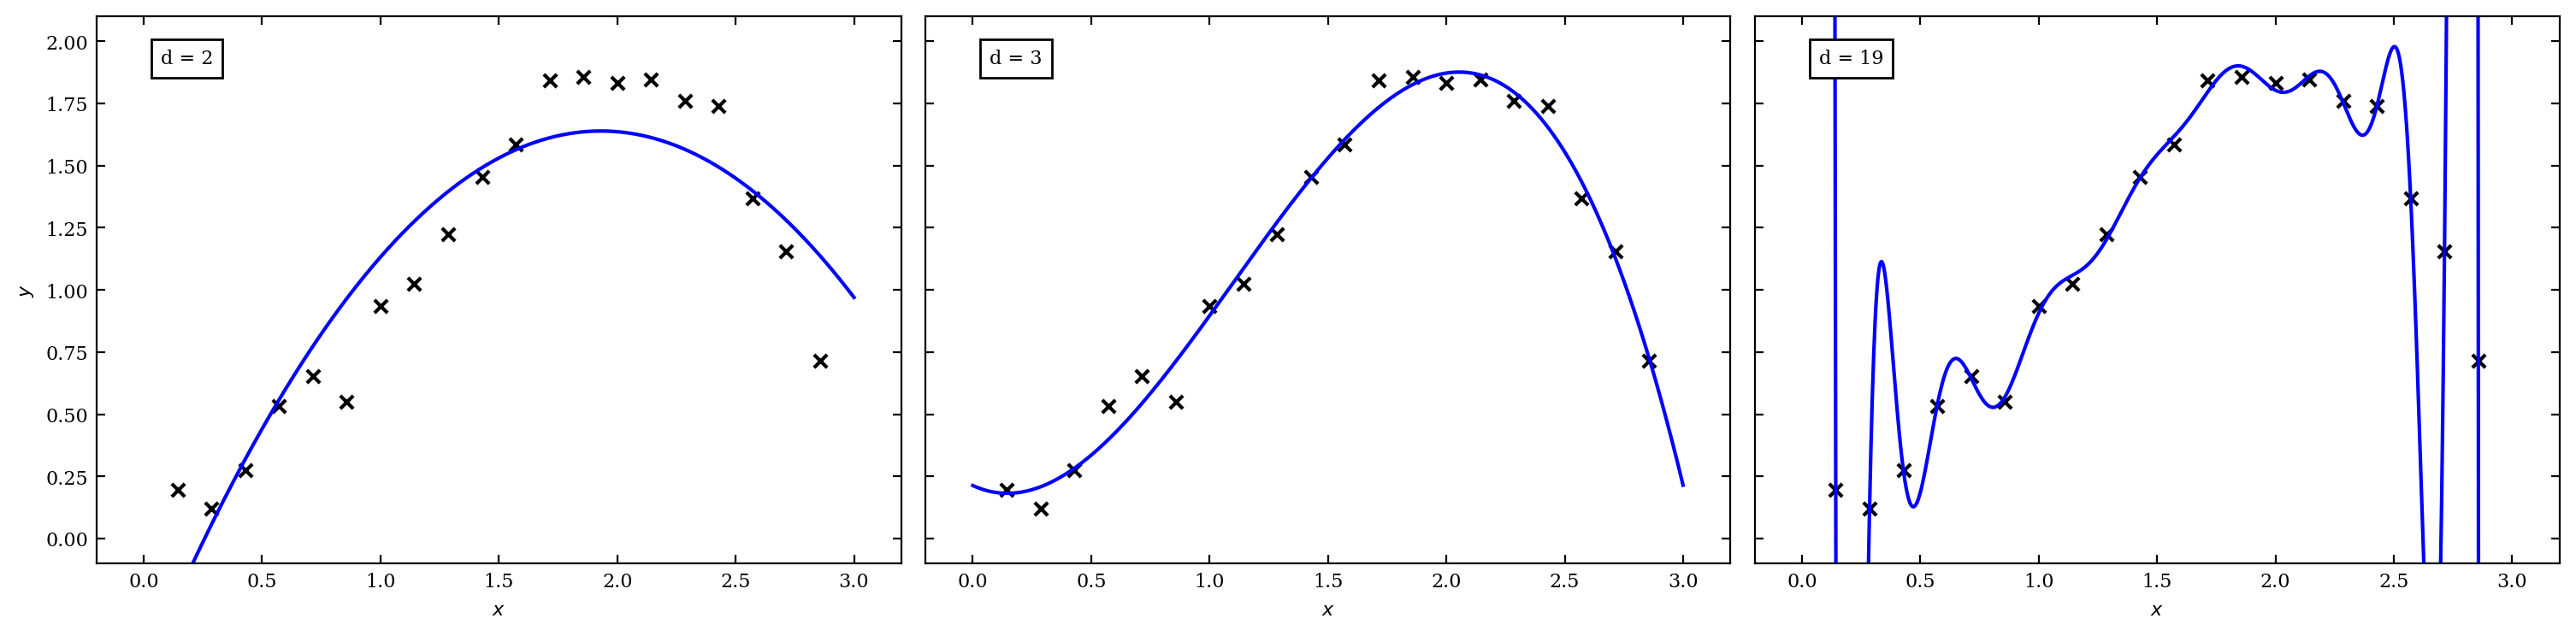

In [45]:
# Ivezic v2, Figure 8.13, panels made bigger by GTR and sizing altered by SRT
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from matplotlib import ticker
from matplotlib.patches import FancyArrow

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

#------------------------------------------------------------
# Define our functional form
def func(x, dy=0.1):
    return np.random.normal(np.sin(x) * x, dy)

#------------------------------------------------------------
# select the (noisy) data
np.random.seed(0)
x = np.linspace(0, 3, 22)[1:-1]
dy = 0.1
y = func(x, dy)

#------------------------------------------------------------
# Select the cross-validation points
np.random.seed(1)
x_cv = 3 * np.random.random(20)
y_cv = func(x_cv)

x_fit = np.linspace(0, 3, 1000)

#------------------------------------------------------------
# Second figure: plot fit for several orders of polynomial
fig = plt.figure(figsize=(16, 4))
fig.subplots_adjust(wspace=0.03, bottom=0.15,
                    top=0.95, left=0.07, right=0.97)

for i, d in enumerate([2, 3, 19]):  #Try 2nd, 3rd and 19th order
    ax = fig.add_subplot(131 + i)
    ax.scatter(x, y, marker='x', c='k', s=30)

    p = np.polyfit(x, y, d)
    y_fit = np.polyval(p, x_fit)

    ax.plot(x_fit, y_fit, '-b')
    ax.set_ylim(-0.1, 2.1)
    ax.set_xlim(-0.2, 3.2)
    if i in (1, 2):
        ax.yaxis.set_major_formatter(plt.NullFormatter())
    else:
        ax.set_ylabel('$y$')
    ax.set_xlabel('$x$')
    ax.text(0.08, 0.94, "d = %i" % d, transform=ax.transAxes,
            ha='left', va='top',
            bbox=dict(ec='k', fc='w'))

plt.show()

We can see a cubic is quite a good estimate, as it seems relatively unbiased and lacks the high variance of the degree = 19 fit which is unbiased but clearly overfit. 

The way we choose the correct answer in this case is cross-validation.

### Cross Validation

We have spoken about k-fold cross validation but I also need a recap for sure, so:

- Split the data into $k+1$ subsets, this will have the test set and the $k$ cross validation sets. We can usually do this through random shufflings with equal number of points.
- $k$ models are trains, each time leave out one of the cross validation sets so we can measure the cross validation error.
- The final training and cross validation error can be found through the mean/median of the set of results

If we have more regression coefficients, we improve the ability for the model to fit all the points, but at the expense of model complexity and variance. So we need a trade off between bias and variance.

So we use a training set (50 - 70%) of the sample, a cross validation set (15-25%) of the sample and a test set (15-25%).

We reason for both the training and cross validation sets are:
- The model parameters, $\theta$ are learned through the training set
- Whereas, the hyperparameters (so for our case here the model degree) is learned from the cross validation set

> Then the test set gives us the best estimate of the error expected for a new set of unlabeled data




C:\Users\krist\AppData\Local\Temp\ipykernel_6112\2438674024.py:46: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x, y, d[i])
C:\Users\krist\AppData\Local\Temp\ipykernel_6112\2438674024.py:46: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x, y, d[i])
C:\Users\krist\AppData\Local\Temp\ipykernel_6112\2438674024.py:46: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x, y, d[i])


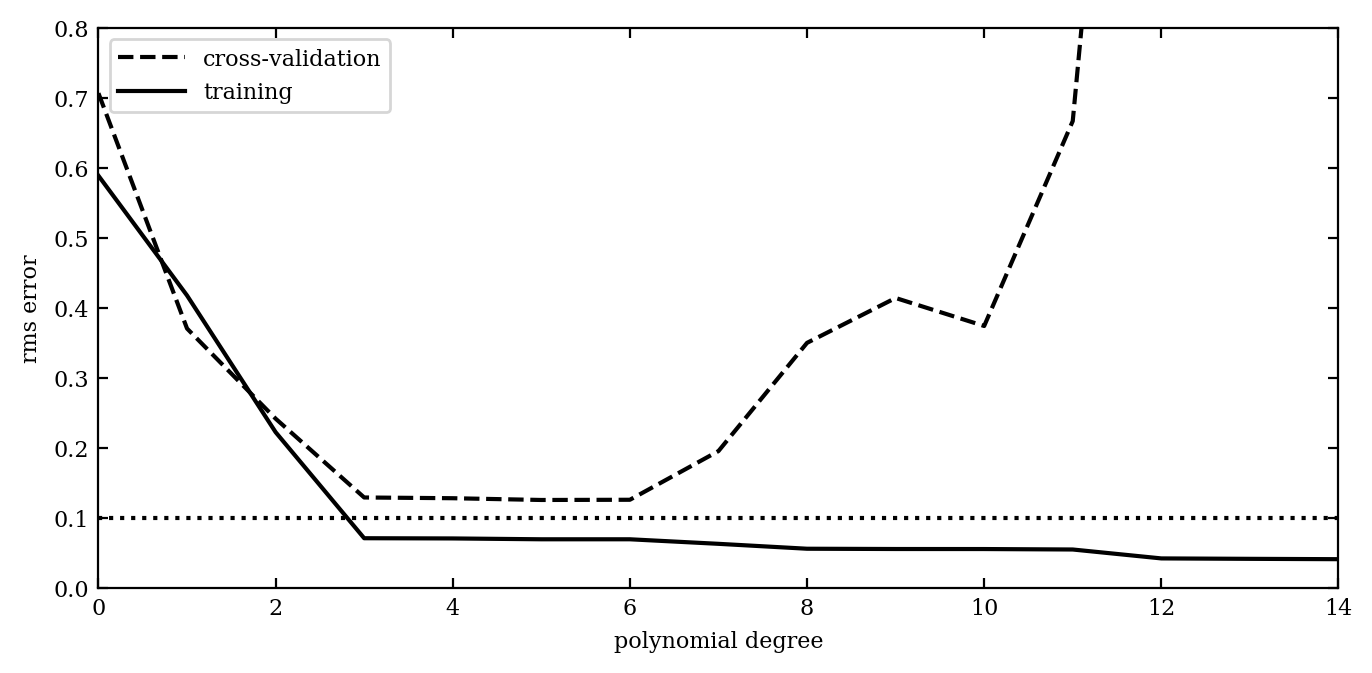

In [46]:
# Ivezic v2, Figure 8.14, panels made bigger by GTR
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

#------------------------------------------------------------
# Define our functional form
def func(x, dy=0.1):
    return np.random.normal(np.sin(x) * x, dy)

#------------------------------------------------------------
# select the (noisy) data
np.random.seed(0)
x = np.linspace(0, 3, 22)[1:-1]
dy = 0.1
y = func(x, dy)

#------------------------------------------------------------
# Select the cross-validation points
np.random.seed(1)
x_cv = 3 * np.random.random(20)
y_cv = func(x_cv)

x_fit = np.linspace(0, 3, 1000)

#------------------------------------------------------------
# Third figure: plot errors as a function of polynomial degree d
d = np.arange(0, 21)
training_err = np.zeros(d.shape)
crossval_err = np.zeros(d.shape)

fig = plt.figure(figsize=(8, 8))
for i in range(len(d)):
    p = np.polyfit(x, y, d[i])
    training_err[i] = np.sqrt(np.sum((np.polyval(p, x) - y) ** 2)
                              / len(y))
    crossval_err[i] = np.sqrt(np.sum((np.polyval(p, x_cv) - y_cv) ** 2)
                              / len(y_cv))

BIC_train = np.sqrt(len(y)) * training_err / dy + d * np.log(len(y))
BIC_crossval = np.sqrt(len(y)) * crossval_err / dy + d * np.log(len(y))

ax = fig.add_subplot(211)
ax.plot(d, crossval_err, '--k', label='cross-validation')
ax.plot(d, training_err, '-k', label='training')
ax.plot(d, 0.1 * np.ones(d.shape), ':k')

ax.set_xlim(0, 14)
ax.set_ylim(0, 0.8)

ax.set_xlabel('polynomial degree')
ax.set_ylabel('rms error')
ax.legend(loc=2)

#ax = fig.add_subplot(212)
#ax.plot(d, BIC_crossval, '--k', label='cross-validation')
#ax.plot(d, BIC_train, '-k', label='training')

#ax.set_xlim(0, 14)
#ax.set_ylim(0, 100)

#ax.legend(loc=2)
#ax.set_xlabel('polynomial degree')
#ax.set_ylabel('BIC')

plt.show()

- For low order, both the training and Cross validation errors are high. This is due to high bias, and we are underfitting the data
- For high order, the training error becomes small, but the cross validation error is large. This shows a high variance model that has overfit the data

### Learning Curves

These plot a machine learning model's performance on the y-axis against the size of the training data set on the x-axis. They help determine if collecting more data will improve the model or if the performance has plateaued. Here we are trying to improve the quality of the data, rather than getting a better model for the data as above.

We can compute the training and cross validation errors as a function of the number of training points.
- The training errors increase with $N_{train}$ as it is easier to fit models with less data
- The Cross validation error decreases with $N_{train}$. A greater number of training points reduce the chances of overfitting, which means there will be better performance of the model in the cross validation stage.

### We will inspect the code tomorrow




Some other resources used:

[Density Estimation with Mixture models (start)](https://www.youtube.com/watch?v=a1pvm1QGXYg&t=20s)

